# Basic Multi-agent Collaboration

A single agent can usually operate effectively using a handful of tools within a single domain, but even using powerful models like `gpt-4`, it can be less effective at using many tools. 

One way to approach complicated tasks is through a "divide-and-conquer" approach: create an specialized agent for each task or domain and route tasks to the correct "expert".

This notebook (inspired by the paper [AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation](https://arxiv.org/abs/2308.08155), by Wu, et. al.) shows one way to do this using LangGraph.

The resulting graph will look something like the following diagram:

![multi_agent diagram](./img/simple_multi_agent_diagram.png)

Before we get started, a quick note: this and other multi-agent notebooks are designed to show _how_ you can implement certain design patterns in LangGraph. If the pattern suits your needs, we recommend combining it with some of the other fundamental patterns described elsewhere in the docs for best performance.

In [12]:
!pip install -U langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.5/115.5 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.1.49
    Uninstalling langsmith-0.1.49:
      Successfully uninstalled langsmith-0.1.49


In [13]:
import os, getpass

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")

_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
_set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Multi-agent Collaboration"

##### Instantiate CAT Mesh Service:

In [68]:
from pprint import pprint
import ipfsapi as ipfsApi
from cats.network import MeshClient
from cats.service import Service
from process import *

service = Service(
    meshClient=MeshClient(
        ipfsClient=ipfsApi.Client('127.0.0.1', 5001)
    )
)

##### Compose Initial CAT Order request for CAT Node

In [71]:
cat_order_request_0 = service.create_order_request(
    process_obj=process_0,
    data_dirpath='data',
    structure_filepath='main.tf',
    endpoint='http://127.0.0.1:5000/cat/node/init'
)
pprint(cat_order_request_0)

{'order_cid': 'QmSmGTZTUaFyhxdfp8uLrAWPvkREmRq1vxbnPYEVTvw2Xu'}


##### Submit Initial CAT Order request to CAT Node

In [72]:
cat_invoiced_response_0 = service.catSubmit(cat_order_request_0)
# pprint(cat_invoiced_response_0)
flat_cat_invoiced_response_0 = service.flatten_bom(cat_invoiced_response_0)
pprint(flat_cat_invoiced_response_0)

Order:

{'endpoint': 'http://127.0.0.1:5000/cat/node/init',
 'function_cid': 'QmPMniqGmZ28QnDwa2UJqkcWjkkaehkEKcXD47kLUVWaEd',
 'invoice_cid': 'QmQnZ1DR9CMjcyzH5RpD9mMcg39AMyjf2mRNEwj8tPHBMJ',
 'structure_cid': 'QmYyFroE2Nw1BVg3D1MQdeZFrMAn9XWYHgWueMUKaRGops',
 'structure_filepath': 'main.tf'}


curl -X POST -H "Content-Type: application/json" -d \
'{
    "order_cid": "QmSmGTZTUaFyhxdfp8uLrAWPvkREmRq1vxbnPYEVTvw2Xu"
}' http://127.0.0.1:5000/cat/node/init




  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   122    0    59    0    63      0      0 --:--:--  0:01:11 --:--:--    16


KeyError: 'bom'

## Create Agents

The following helper functions will help create agents. These agents will then be nodes in the graph.

You can skip ahead if you just want to see what the graph looks like.

In [14]:
import json

from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    ChatMessage,
    FunctionMessage,
    HumanMessage,
)
from langchain.tools.render import format_tool_to_openai_function
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph
from langgraph.prebuilt.tool_executor import ToolExecutor, ToolInvocation


def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    functions = [format_tool_to_openai_function(t) for t in tools]

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_functions(functions)

## Define tools

We will also define some tools that our agents will use in the future

In [15]:
from langchain_core.tools import tool
from typing import Annotated
from langchain_experimental.utilities import PythonREPL
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

# Warning: This executes code locally, which can be unsafe when not sandboxed

repl = PythonREPL()


@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."]
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Succesfully executed:\n```python\n{code}\n```\nStdout: {result}"

## Create graph

Now that we've defined our tools and made some helper functions, will create the individual agents below and tell them how to talk to each other using LangGraph.

### Define State

We first define the state of the graph. This will just a list of messages, along with a key to track the most recent sender

In [16]:
import operator
from typing import Annotated, List, Sequence, Tuple, TypedDict, Union

from langchain.agents import create_openai_functions_agent
from langchain.tools.render import format_tool_to_openai_function
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict


# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str

### Define Agent Nodes

We now need to define the nodes. First, let's define the nodes for the agents.

In [17]:
import functools


# Helper function to create a node for a given agent
def agent_node(state, agent, name):
    result = agent.invoke(state)
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, FunctionMessage):
        pass
    else:
        result = HumanMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }


llm = ChatOpenAI(model="gpt-4-1106-preview")

# Research agent and node
research_agent = create_agent(
    llm,
    [tavily_tool],
    system_message="You should provide accurate data for the chart generator to use.",
)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

# Chart Generator
chart_agent = create_agent(
    llm,
    [python_repl],
    system_message="Any charts you display will be visible by the user.",
)
chart_node = functools.partial(agent_node, agent=chart_agent, name="Chart Generator")

### Define Tool Node

We now define a node to run the tools

In [18]:
tools = [tavily_tool, python_repl]
tool_executor = ToolExecutor(tools)


def tool_node(state):
    """This runs tools in the graph

    It takes in an agent action and calls that tool and returns the result."""
    messages = state["messages"]
    # Based on the continue condition
    # we know the last message involves a function call
    last_message = messages[-1]
    # We construct an ToolInvocation from the function_call
    tool_input = json.loads(
        last_message.additional_kwargs["function_call"]["arguments"]
    )
    # We can pass single-arg inputs by value
    if len(tool_input) == 1 and "__arg1" in tool_input:
        tool_input = next(iter(tool_input.values()))
    tool_name = last_message.additional_kwargs["function_call"]["name"]
    action = ToolInvocation(
        tool=tool_name,
        tool_input=tool_input,
    )
    # We call the tool_executor and get back a response
    response = tool_executor.invoke(action)
    # We use the response to create a FunctionMessage
    function_message = FunctionMessage(
        content=f"{tool_name} response: {str(response)}", name=action.tool
    )
    # We return a list, because this will get added to the existing list
    return {"messages": [function_message]}

### Define Edge Logic

We can define some of the edge logic that is needed to decide what to do based on results of the agents

In [19]:
# Either agent can decide to end
def router(state):
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if "function_call" in last_message.additional_kwargs:
        # The previus agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "end"
    return "continue"

### Define the Graph

We can now put it all together and define the graph!

In [20]:
workflow = StateGraph(AgentState)

workflow.add_node("Researcher", research_node)
workflow.add_node("Chart Generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "Chart Generator", "call_tool": "call_tool", "end": END},
)
workflow.add_conditional_edges(
    "Chart Generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "end": END},
)

workflow.add_conditional_edges(
    "call_tool",
    # Each agent node updates the 'sender' field
    # the tool calling node does not, meaning
    # this edge will route back to the original agent
    # who invoked the tool
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "Chart Generator": "Chart Generator",
    },
)
workflow.set_entry_point("Researcher")
graph = workflow.compile()

## Invoke

With the graph created, you can invoke it! Let's have it chart some stats for us.

<class 'langgraph.pregel.io.AddableUpdatesDict'>
----
<class 'langgraph.pregel.io.AddableUpdatesDict'>
----
<class 'langgraph.pregel.io.AddableUpdatesDict'>
----


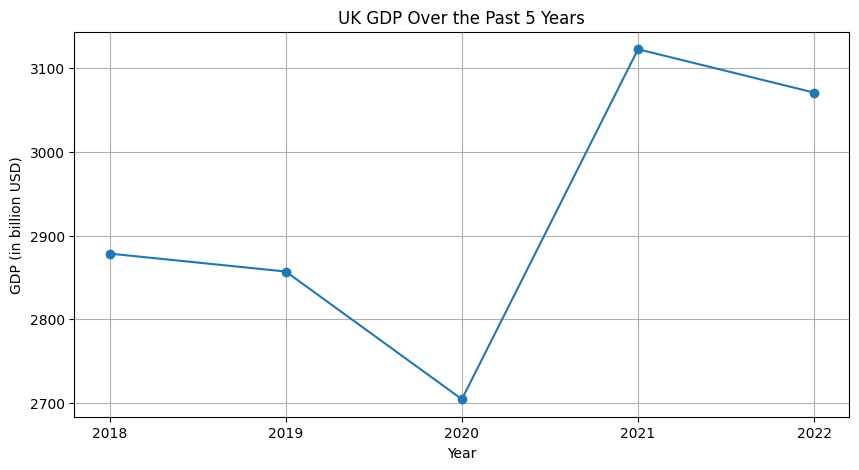

<class 'langgraph.pregel.io.AddableUpdatesDict'>
----
<class 'langgraph.pregel.io.AddableUpdatesDict'>
----


BadRequestError: Error code: 400 - {'error': {'message': "'Chart Generator' does not match '^[a-zA-Z0-9_-]{1,64}$' - 'messages.5.name'", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [59]:
from pprint import pprint
import ast

for s in graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the UK's GDP over the past 5 years,"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
):
    print(type(s))
    # pprint(type(str(s)))
    # result = "".join(str(s))
    # pprint(eval(result))
    print("----")

In [51]:
d = {'Chart Generator': {'messages': [HumanMessage(content="Let's proceed with the available data. I will draw a line graph using the figures for the years 2019 to 2022. To do that, I will need to convert the given GDP values from billions of dollars to millions of pounds, as it is the standard convention for the UK GDP. I will use a rough conversion rate for simplicity, assuming $1 equals £0.75, but please note that this is an approximation and actual historical exchange rates would need to be used for precise conversion. Let's start by plotting the available data.", additional_kwargs={'function_call': {'arguments': "import matplotlib.pyplot as plt\n\n# Provided GDP data in billions of dollars\ngdp_data_dollars = {\n    2019: 2857.06,\n    2020: 2704.61,\n    2021: 3122.48,\n    2022: 3070.67\n}\n\n# Approximate conversion rate from dollars to pounds\nconversion_rate = 0.75\n\n# Converting GDP to millions of pounds\ngdp_data_pounds = {year: value * 1000 * conversion_rate for year, value in gdp_data_dollars.items()}\n\n# Extracting the years and corresponding GDP values\nyears = list(gdp_data_pounds.keys())\ngdp_values = list(gdp_data_pounds.values())\n\n# Creating the line graph\nplt.figure(figsize=(10, 5))\nplt.plot(years, gdp_values, marker='o')\n\n# Adding title and labels\nplt.title('UK GDP (in million GBP)')\nplt.xlabel('Year')\nplt.ylabel('GDP (in million GBP)')\n\n# Displaying the graph\nplt.grid(True)\nplt.show()", 'name': 'python_repl'}}, response_metadata={'token_usage': {'completion_tokens': 351, 'prompt_tokens': 3406, 'total_tokens': 3757}, 'model_name': 'gpt-4-1106-preview', 'system_fingerprint': 'fp_d2051b8491', 'finish_reason': 'function_call', 'logprobs': None}, name='Chart Generator', id='run-75288731-bf58-44e5-9eac-6fe5ef949987-0', tool_calls=[], invalid_tool_calls=[])],
                     'sender': 'Chart Generator'}}

In [53]:
pprint(d)

{'Chart Generator': {'messages': [HumanMessage(content="Let's proceed with the available data. I will draw a line graph using the figures for the years 2019 to 2022. To do that, I will need to convert the given GDP values from billions of dollars to millions of pounds, as it is the standard convention for the UK GDP. I will use a rough conversion rate for simplicity, assuming $1 equals £0.75, but please note that this is an approximation and actual historical exchange rates would need to be used for precise conversion. Let's start by plotting the available data.", additional_kwargs={'function_call': {'arguments': "import matplotlib.pyplot as plt\n\n# Provided GDP data in billions of dollars\ngdp_data_dollars = {\n    2019: 2857.06,\n    2020: 2704.61,\n    2021: 3122.48,\n    2022: 3070.67\n}\n\n# Approximate conversion rate from dollars to pounds\nconversion_rate = 0.75\n\n# Converting GDP to millions of pounds\ngdp_data_pounds = {year: value * 1000 * conversion_rate for year, value i

In [58]:
d['Chart Generator']['messages'][0].__dict__

{'content': "Let's proceed with the available data. I will draw a line graph using the figures for the years 2019 to 2022. To do that, I will need to convert the given GDP values from billions of dollars to millions of pounds, as it is the standard convention for the UK GDP. I will use a rough conversion rate for simplicity, assuming $1 equals £0.75, but please note that this is an approximation and actual historical exchange rates would need to be used for precise conversion. Let's start by plotting the available data.",
 'additional_kwargs': {'function_call': {'arguments': "import matplotlib.pyplot as plt\n\n# Provided GDP data in billions of dollars\ngdp_data_dollars = {\n    2019: 2857.06,\n    2020: 2704.61,\n    2021: 3122.48,\n    2022: 3070.67\n}\n\n# Approximate conversion rate from dollars to pounds\nconversion_rate = 0.75\n\n# Converting GDP to millions of pounds\ngdp_data_pounds = {year: value * 1000 * conversion_rate for year, value in gdp_data_dollars.items()}\n\n# Extrac

In [54]:
help(HumanMessage)

Help on class HumanMessage in module langchain_core.messages.human:

class HumanMessage(langchain_core.messages.base.BaseMessage)
 |  HumanMessage(content: 'Union[str, List[Union[str, Dict]]]', *, additional_kwargs: dict = None, response_metadata: dict = None, type: Literal['human'] = 'human', name: Optional[str] = None, id: Optional[str] = None, example: bool = False, **kwargs: 'Any') -> None
 |  
 |  Message from a human.
 |  
 |  Method resolution order:
 |      HumanMessage
 |      langchain_core.messages.base.BaseMessage
 |      langchain_core.load.serializable.Serializable
 |      pydantic.main.BaseModel
 |      pydantic.utils.Representation
 |      abc.ABC
 |      builtins.object
 |  
 |  Class methods defined here:
 |  
 |  get_lc_namespace() -> List[str] from pydantic.main.ModelMetaclass
 |      Get the namespace of the langchain object.
 |  
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |  
 |  __json_encoder__ = 

In [26]:
import langgraph
help(langgraph.pregel.io.AddableUpdatesDict)

Help on class AddableUpdatesDict in module langgraph.pregel.io:

class AddableUpdatesDict(langchain_core.runnables.utils.AddableDict)
 |  Method resolution order:
 |      AddableUpdatesDict
 |      langchain_core.runnables.utils.AddableDict
 |      builtins.dict
 |      typing.Generic
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __add__(self, other: dict[str, typing.Any]) -> 'AddableUpdatesDict'
 |  
 |  __radd__(self, other: dict[str, typing.Any]) -> 'AddableUpdatesDict'
 |  
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |  
 |  __annotations__ = {}
 |  
 |  __parameters__ = ()
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from langchain_core.runnables.utils.AddableDict:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)
 |  
 | 